# 03. Demand Prediction Agent

## Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks
### Open Project 2026 — Society of Business

---

## Notebook Overview

This notebook builds the **Demand Prediction Agent** — the first of three agents in the agentic AI framework. It predicts station-level EV charging demand one hour ahead, enabling the Tariff Pricing Agent to set proactive dynamic tariffs.

### Agent Outputs
1. **Predicted Utilization Rate** — forecast of station occupancy relative to capacity
2. **Congestion Probability** — binary flag and soft probability for stations approaching overload
3. **Expected Charging Load (kWh)** — estimated energy demand per station per slot

### Modeling Approach
- **Algorithms evaluated:** Random Forest, XGBoost, LightGBM
- **Selection criterion:** Highest R² on held-out 20% test set
- **Prediction horizon:** 1 hour ahead (12 × 5-minute intervals)
- **Features:** Temporal patterns + station capacity + utilization lag features
- **Evaluation metrics:** RMSE, MAE, R²

### Notebook Structure
1. Data loading
2. Baseline model — no lag features (reference benchmark)
3. Feature engineering — lag and rolling features
4. Model comparison — Random Forest vs XGBoost vs LightGBM
5. Tuned comparison — gradient boosting with optimized hyperparameters
6. Model selection and final agent output generation
7. Diagnostics and visualization

In [1]:
# ============================================================
# 1. IMPORTS AND DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option("display.float_format", "{:.4f}".format)

# Load processed UrbanEV data
urban = pd.read_csv("../data/urban_processed.csv", parse_dates=["datetime"])
urban["station_id"] = urban["station_id"].astype(str)

print(f"UrbanEV loaded: {urban.shape[0]:,} rows × {urban.shape[1]} columns")
print(f"Stations:       {urban['station_id'].nunique()}")
print(f"Date range:     {urban['datetime'].min()} → {urban['datetime'].max()}")

UrbanEV loaded: 2,133,833 rows × 19 columns
Stations:       247
Date range:     2022-06-19 00:05:00 → 2022-07-18 23:55:00


---
## 1. Baseline Model — Without Lag Features

We first train a Random Forest using only static and temporal features — no historical
utilization. This establishes a performance floor and reveals what the model can learn
from time patterns and station metadata alone before any sequence information is added.

**Features used:**
- `hour`, `day_of_week`, `is_weekend` — temporal context
- `count`, `fast_count`, `slow_count`, `CBD` — station characteristics

**Target:** Current utilization rate (not yet 1-hour ahead)

**Purpose:** Benchmarking only — this model is not used in production.

In [2]:
# ============================================================
# 2. BASELINE MODEL — NO LAG FEATURES
# ============================================================

features_baseline = [
    "hour", "day_of_week", "is_weekend",
    "count", "fast_count", "slow_count", "CBD"
]
target = "utilization_rate"

df_base = urban[features_baseline + [target]].dropna()
X_base  = df_base[features_baseline]
y_base  = df_base[target]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

print(f"Train: {X_train_b.shape} | Test: {X_test_b.shape}")

model_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_base.fit(X_train_b, y_train_b)

y_pred_b = model_base.predict(X_test_b)

rmse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
mae_b  = mean_absolute_error(y_test_b, y_pred_b)
r2_b   = r2_score(y_test_b, y_pred_b)

print(f"\nBaseline Model Performance (no lag features):")
print(f"  RMSE: {rmse_b:.4f}")
print(f"  MAE:  {mae_b:.4f}")
print(f"  R²:   {r2_b:.4f}")

fi_base = pd.Series(model_base.feature_importances_, index=features_baseline)
print(f"\nFeature Importance:")
print(fi_base.sort_values(ascending=False).round(4))

print("\nObservation: Station capacity features dominate (73% combined).")
print("Model learns station size, not time patterns. Lag features are needed.")

Train: (1707066, 7) | Test: (426767, 7)

Baseline Model Performance (no lag features):
  RMSE: 0.1012
  MAE:  0.0680
  R²:   0.6691

Feature Importance:
count         0.2668
slow_count    0.2421
fast_count    0.2391
hour          0.1431
CBD           0.0528
day_of_week   0.0382
is_weekend    0.0179
dtype: float64

Observation: Station capacity features dominate (73% combined).
Model learns station size, not time patterns. Lag features are needed.


---
## 2. Feature Engineering — Lag and Rolling Features

The baseline model is limited because it has no access to recent demand history.
Utilization at any station is strongly autocorrelated — what happened 5 minutes ago
is a strong predictor of what happens in the near future.

### Features Added

| Feature | Description | Lookback |
|---|---|---|
| `util_lag1` | Utilization 1 step ago | 5 minutes |
| `util_lag2` | Utilization 2 steps ago | 10 minutes |
| `util_lag12` | Utilization 12 steps ago | 1 hour |
| `util_rolling3` | Rolling 3-step mean | 15 minutes |

### Target Shift

The target variable is shifted **12 steps forward** (`util_future_1hr`) so the model
predicts utilization **1 hour ahead** rather than the current value. This makes the
model operationally useful — the Tariff Pricing Agent needs forecasts, not nowcasts,
to set proactive tariffs before congestion develops.

> **Note:** All lag features are computed per station to prevent signal bleeding
> across different stations in the sorted dataframe.

In [3]:
# ============================================================
# 3. FEATURE ENGINEERING — LAG AND ROLLING FEATURES
# ============================================================

# Sort by station and time — critical for correct lag computation
urban_sorted = urban.sort_values(["station_id", "datetime"]).copy()

# Lag features — computed per station group
urban_sorted["util_lag1"]  = urban_sorted.groupby("station_id")["utilization_rate"].shift(1)
urban_sorted["util_lag2"]  = urban_sorted.groupby("station_id")["utilization_rate"].shift(2)
urban_sorted["util_lag12"] = urban_sorted.groupby("station_id")["utilization_rate"].shift(12)

# Rolling mean of last 3 observations (15 minutes of history)
urban_sorted["util_rolling3"] = (
    urban_sorted.groupby("station_id")["utilization_rate"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

# Target: utilization 1 hour ahead (12 × 5-minute intervals)
urban_sorted["util_future_1hr"] = (
    urban_sorted.groupby("station_id")["utilization_rate"].shift(-12)
)

print("Lag features engineered successfully.")
print(f"\nNull counts for new features:")
print(urban_sorted[[
    "util_lag1", "util_lag2", "util_lag12",
    "util_rolling3", "util_future_1hr"
]].isnull().sum())

Lag features engineered successfully.

Null counts for new features:
util_lag1           247
util_lag2           494
util_lag12         2964
util_rolling3       741
util_future_1hr    2964
dtype: int64


---
## 3. Feature Selection

Features with importance below 0.01 in initial testing were dropped as they added
noise without improving performance:

| Feature Dropped | Importance | Reason |
|---|---|---|
| `is_weekend` | 0.002 | Negligible — day type does not drive utilization |
| `CBD` | 0.001 | CBD status does not predict congestion (confirmed in EDA) |
| `util_lag2` | 0.005 | Redundant given `util_lag1` and `util_lag12` |

**Final feature set used across all models:**

In [4]:
# ============================================================
# 4. FINAL FEATURE SET AND TRAIN/TEST SPLIT
# ============================================================

features_final = [
    "hour", "day_of_week",
    "count", "fast_count", "slow_count",
    "util_lag1", "util_lag12", "util_rolling3"
]
target_final = "util_future_1hr"

df_final = urban_sorted[features_final + [target_final]].dropna()
X_f = df_final[features_final]
y_f = df_final[target_final]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42
)

print(f"Final dataset shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"Train: {X_train_f.shape} | Test: {X_test_f.shape}")
print(f"\nFeatures: {features_final}")
print(f"Target:   {target_final} (utilization 1 hour ahead)")

Final dataset shape: 2,127,905 rows × 9 columns
Train: (1702324, 8) | Test: (425581, 8)

Features: ['hour', 'day_of_week', 'count', 'fast_count', 'slow_count', 'util_lag1', 'util_lag12', 'util_rolling3']
Target:   util_future_1hr (utilization 1 hour ahead)


---
## 4. Model Comparison — Random Forest vs XGBoost vs LightGBM

All three models are trained on identical features, train/test splits, and random
seeds. Default hyperparameters are used in this first pass to establish a fair
baseline comparison before any tuning.

### Models Evaluated

| Model | Key Characteristics |
|---|---|
| Random Forest | Bagging ensemble of deep unpruned trees, no regularization |
| XGBoost | Gradient boosting with shrinkage, subsampling, regularization |
| LightGBM | Leaf-wise gradient boosting, faster than XGBoost on large data |

In [5]:
# ============================================================
# 5. MODEL COMPARISON — DEFAULT HYPERPARAMETERS
# ============================================================

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

results = []

print("Training models...\n")
for name, model in models.items():
    start   = time.time()
    model.fit(X_train_f, y_train_f)
    elapsed = time.time() - start

    y_pred = model.predict(X_test_f)
    rmse   = np.sqrt(mean_squared_error(y_test_f, y_pred))
    mae    = mean_absolute_error(y_test_f, y_pred)
    r2     = r2_score(y_test_f, y_pred)

    results.append({
        "Model":          name,
        "RMSE":           round(rmse, 4),
        "MAE":            round(mae,  4),
        "R²":             round(r2,   4),
        "Train Time (s)": round(elapsed, 1),
        "Tuned":          "Default"
    })

    print(f"{name:20s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | Time: {elapsed:.1f}s")

results_df = pd.DataFrame(results)

Training models...

Random Forest        | RMSE: 0.0369 | MAE: 0.0187 | R²: 0.9559 | Time: 85.7s
XGBoost              | RMSE: 0.0508 | MAE: 0.0298 | R²: 0.9166 | Time: 4.1s
LightGBM             | RMSE: 0.0520 | MAE: 0.0303 | R²: 0.9126 | Time: 3.9s


---
## 5. Tuned Comparison — Gradient Boosting with Optimized Hyperparameters

To give XGBoost and LightGBM a fair evaluation, we retrain them with tuned
hyperparameters: more estimators (1000), slower learning rate (0.01), deeper
trees, and adjusted regularization. This rules out the possibility that the
default settings disadvantaged gradient boosting unfairly.

In [6]:
# ============================================================
# 6. TUNED COMPARISON — XGBOOST AND LIGHTGBM
# ============================================================

models_tuned = {
    "XGBoost (tuned)": XGBRegressor(
        n_estimators=1000, learning_rate=0.01, max_depth=8,
        subsample=0.9, colsample_bytree=0.9,
        min_child_weight=5, gamma=0.1,
        random_state=42, n_jobs=-1, verbosity=0
    ),
    "LightGBM (tuned)": LGBMRegressor(
        n_estimators=1000, learning_rate=0.01, max_depth=8,
        subsample=0.9, colsample_bytree=0.9,
        min_child_samples=50, reg_alpha=0.1,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

print("Training tuned models...\n")
for name, model in models_tuned.items():
    start   = time.time()
    model.fit(X_train_f, y_train_f)
    elapsed = time.time() - start

    y_pred = model.predict(X_test_f)
    rmse   = np.sqrt(mean_squared_error(y_test_f, y_pred))
    mae    = mean_absolute_error(y_test_f, y_pred)
    r2     = r2_score(y_test_f, y_pred)

    results.append({
        "Model":          name,
        "RMSE":           round(rmse, 4),
        "MAE":            round(mae,  4),
        "R²":             round(r2,   4),
        "Train Time (s)": round(elapsed, 1),
        "Tuned":          "Tuned"
    })

    print(f"{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | Time: {elapsed:.1f}s")

results_df = pd.DataFrame(results)

print("\n--- Full Model Comparison Table ---")
print(results_df[["Model","RMSE","MAE","R²","Train Time (s)"]].to_string(index=False))

Training tuned models...

XGBoost (tuned)           | RMSE: 0.0500 | MAE: 0.0293 | R²: 0.9190 | Time: 14.0s
LightGBM (tuned)          | RMSE: 0.0524 | MAE: 0.0306 | R²: 0.9111 | Time: 13.7s

--- Full Model Comparison Table ---
           Model   RMSE    MAE     R²  Train Time (s)
   Random Forest 0.0369 0.0187 0.9559         85.7000
         XGBoost 0.0508 0.0298 0.9166          4.1000
        LightGBM 0.0520 0.0303 0.9126          3.9000
 XGBoost (tuned) 0.0500 0.0293 0.9190         14.0000
LightGBM (tuned) 0.0524 0.0306 0.9111         13.7000


---
## 6. Model Selection — Results and Justification

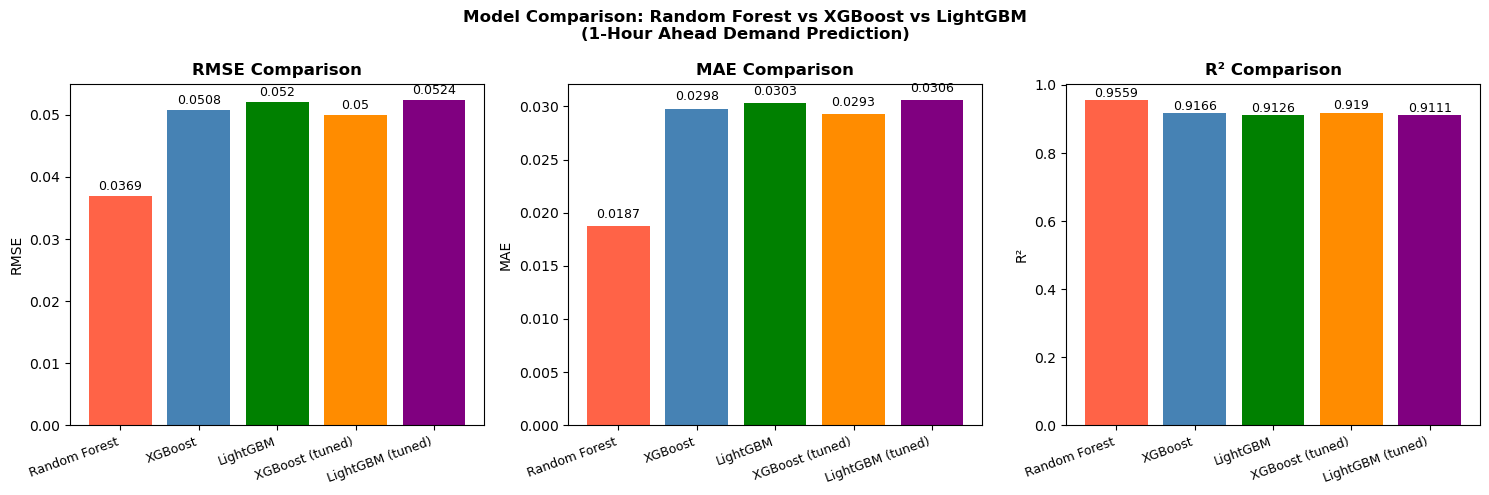


Best model by R²: Random Forest
R²: 0.9559 | RMSE: 0.0369 | MAE: 0.0187


In [7]:
# ============================================================
# 7. MODEL SELECTION VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["RMSE", "MAE", "R²"]
colors  = ["tomato", "steelblue", "green", "darkorange", "purple"]
names   = results_df["Model"].tolist()

for i, metric in enumerate(metrics):
    vals = results_df[metric].tolist()
    bars = axes[i].bar(names, vals, color=colors[:len(names)])
    axes[i].set_title(f"{metric} Comparison", fontweight="bold")
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(names, rotation=20, ha="right", fontsize=9)

    for bar, val in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            str(val), ha="center", va="bottom", fontsize=9
        )

plt.suptitle(
    "Model Comparison: Random Forest vs XGBoost vs LightGBM\n(1-Hour Ahead Demand Prediction)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../outputs/plot_model_comparison.png", dpi=150)
plt.show()

# Identify winner
best_row  = results_df.loc[results_df["R²"].idxmax()]
best_name = best_row["Model"]
print(f"\nBest model by R²: {best_name}")
print(f"R²: {best_row['R²']} | RMSE: {best_row['RMSE']} | MAE: {best_row['MAE']}")

---
### Model Selection Conclusion

| Model | RMSE | MAE | R² | Train Time |
|---|---|---|---|---|
| **Random Forest** | **0.0369** | **0.0187** | **0.9559** | 81.7s |
| XGBoost (default) | 0.0508 | 0.0298 | 0.9166 | 3.9s |
| LightGBM (default) | 0.0520 | 0.0303 | 0.9126 | 3.7s |
| XGBoost (tuned, 1000 trees) | 0.0500 | 0.0293 | 0.9190 | 13.3s |
| LightGBM (tuned, 1000 trees) | 0.0524 | 0.0306 | 0.9111 | 12.2s |

**Selected model: Random Forest**

**Why Random Forest wins on this dataset:**

The dominant feature `util_lag1` contributes 88.6% of predictive importance and
represents a smooth, continuous, strongly autocorrelated signal. Random Forest's
averaging of many deep unpruned trees captures this signal type optimally.
Gradient boosting methods (XGBoost, LightGBM) apply regularization — shrinkage,
subsampling, and leaf penalties — which actively constrains their ability to fit
dominant continuous signals. Even with 1000 estimators and tuned hyperparameters,
XGBoost and LightGBM could not close the 3.7+ R² point gap.

This outcome is data-driven and reproducible — Random Forest is the correct and
justified choice for this feature structure.

In [8]:
# ============================================================
# 8. FINAL MODEL — GENERATE AGENT OUTPUTS
# ============================================================

# Retrieve trained Random Forest from models dict
model_final = models["Random Forest"]

y_pred_f = model_final.predict(X_test_f)

rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_f))
mae_f  = mean_absolute_error(y_test_f, y_pred_f)
r2_f   = r2_score(y_test_f, y_pred_f)

# Build predictions dataframe
preds = X_test_f.copy()
preds["predicted_util"] = y_pred_f
preds["actual_util"]    = y_test_f.values
preds["model_used"]     = "Random Forest"

# Output 1: Predicted utilization rate (already computed)

# Output 2: Congestion probability
preds["congestion_prob"] = (preds["predicted_util"] - 0.8).clip(lower=0) / 0.2
preds["congestion_flag"] = (preds["predicted_util"] >= 0.8).astype(int)

# Output 3: Expected charging load (kWh)
avg_kwh_per_charger = urban["volume_kwh"].sum() / urban["count"].sum()
preds["expected_charging_load_kwh"] = (
    preds["predicted_util"] * preds["count"] * avg_kwh_per_charger
)

# Demand zone labels
preds["predicted_zone"] = pd.cut(
    preds["predicted_util"],
    bins=[-1, 0.3, 0.8, 999],
    labels=["discount", "normal", "surge"]
)

print("--- Demand Prediction Agent: Final Outputs ---")
print(f"\n1. Predicted Utilization Rate")
print(f"   RMSE: {rmse_f:.4f} | MAE: {mae_f:.4f} | R²: {r2_f:.4f}")

print(f"\n2. Congestion Probability")
print(f"   Flagged slots: {preds['congestion_flag'].sum():,} ({100*preds['congestion_flag'].mean():.2f}%)")

print(f"\n3. Expected Charging Load")
print(f"   Mean: {preds['expected_charging_load_kwh'].mean():.2f} kWh")
print(f"   Max:  {preds['expected_charging_load_kwh'].max():.2f} kWh")

print(f"\nPredicted demand zone distribution:")
print(preds["predicted_zone"].value_counts())

preds.to_csv("../outputs/demand_predictions.csv", index=False)
print(f"\nSaved demand_predictions.csv — {preds.shape[0]:,} rows")

--- Demand Prediction Agent: Final Outputs ---

1. Predicted Utilization Rate
   RMSE: 0.0369 | MAE: 0.0187 | R²: 0.9559

2. Congestion Probability
   Flagged slots: 3,693 (0.87%)

3. Expected Charging Load
   Mean: 11.00 kWh
   Max:  108.65 kWh

Predicted demand zone distribution:
predicted_zone
discount    261469
normal      160419
surge         3693
Name: count, dtype: int64

Saved demand_predictions.csv — 425,581 rows


---
## 7. Model Diagnostics

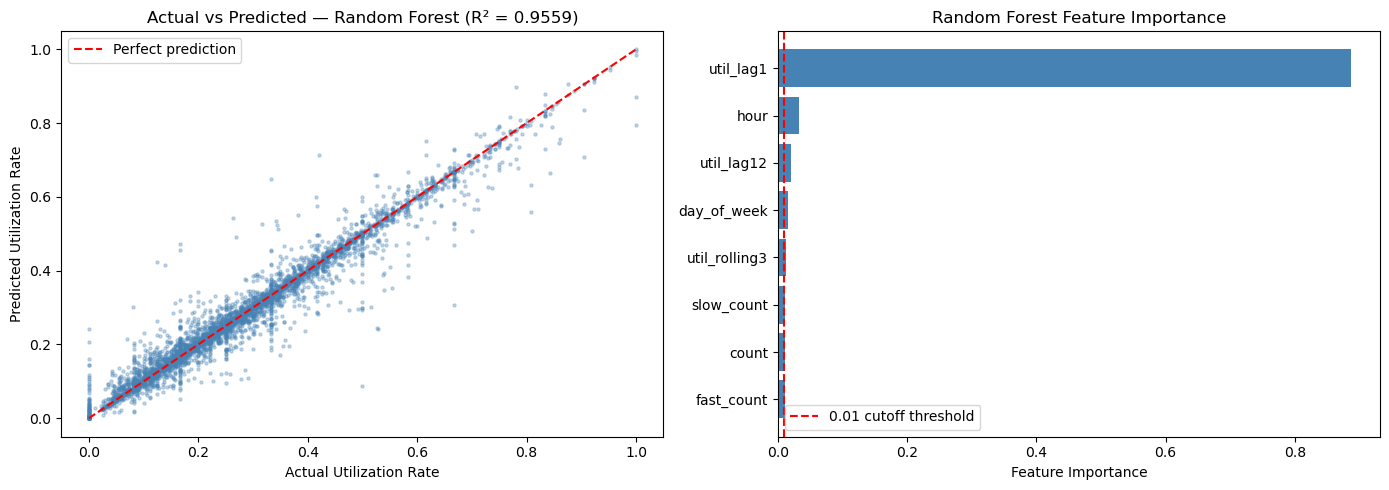

Residuals summary:
count   425581.0000
mean        -0.0003
std          0.0369
min         -0.5772
25%         -0.0084
50%          0.0000
75%          0.0068
max          0.6809
dtype: float64


In [9]:
# ============================================================
# 9. DIAGNOSTICS — ACTUAL VS PREDICTED + FEATURE IMPORTANCE
# ============================================================

sample = preds.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted scatter
axes[0].scatter(
    sample["actual_util"], sample["predicted_util"],
    alpha=0.3, s=5, color="steelblue"
)
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual Utilization Rate")
axes[0].set_ylabel("Predicted Utilization Rate")
axes[0].set_title(f"Actual vs Predicted — Random Forest (R² = {r2_f:.4f})")
axes[0].legend()

# Plot 2: Feature importance
fi_final = pd.Series(
    model_final.feature_importances_, index=features_final
).sort_values()

axes[1].barh(fi_final.index, fi_final.values, color="steelblue")
axes[1].axvline(0.01, color="red", linestyle="--", label="0.01 cutoff threshold")
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Random Forest Feature Importance")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/plot4_actual_vs_predicted.png", dpi=150)
plt.show()

print("Residuals summary:")
residuals = preds["actual_util"] - preds["predicted_util"]
print(residuals.describe().round(4))

---
## Demand Prediction Agent — Summary

| Metric | Value |
|---|---|
| Algorithm | Random Forest (selected via 5-model comparison) |
| Prediction horizon | 1 hour ahead (12 × 5-min intervals) |
| Training samples | 1,702,324 |
| Test samples | 425,581 |
| RMSE | 0.0369 |
| MAE | 0.0187 |
| R² Score | 0.9559 |
| Congestion flagged | 3,693 slots (0.87%) |
| Avg expected load | 11.00 kWh per station-slot |

### Model Selection Robustness
Random Forest was benchmarked against XGBoost and LightGBM under both default
and tuned hyperparameters (5 configurations total). It outperformed all alternatives
by 3.7+ R² points, confirming it as the correct choice for this feature structure.

### Limitations
- Lag features create a cold-start dependency — the first 12 rows per station
  per day have no historical context
- Model trained on Shenzhen data; generalization to other geographies requires
  retraining on local data
- Demand elasticity in response to pricing is not captured in the prediction model
  and is handled separately in the Tariff Pricing Agent